In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# A solvent above a polymer, where mole fraction stops being useful (benzene / polyisobutylene)

This notebook works **Illustration 10.2-7** and recomputes both of its figures: the partial
pressure of benzene above benzene + polyisobutylene mixtures at 298.15 K and at 312.75 K,
from the Flory-Huggins model, at two values of the interaction parameter $\chi$.

**Why a polymer solution needs its own model, in one number.** At 5 weight percent benzene the
*mole* fraction of benzene is **0.964** — because one PIB molecule weighs 40 000 and one
benzene weighs 78, so a little benzene is an enormous number of molecules. A model built on
mole fractions would call that mixture nearly pure benzene. Its *volume* fraction is 0.045,
which is what actually controls the physics, and Flory-Huggins is that substitution and
nothing more.

The practical question behind it is polymer devolatilization: how hard is it to pull the last
of the solvent out of a polymer? The answer is in the shape of these curves at the left-hand
edge.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## The illustration's data, and the two size parameters that come out of it

Everything below is from the illustration's own Data block. The only quantities that have to
be derived are the number of monomers per chain and the molecular size ratio $m$, and both are
done explicitly because $m$ is the parameter that makes this a polymer problem:

$$n = \frac{40\,000}{104} , \qquad
  \underline{V}_{\rm PIB} = n\,\underline{V}_{\rm monomer} , \qquad
  m = \frac{\underline{V}_{\rm PIB}}{\underline{V}_{\rm B}}$$

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo.activity_models import FloryHuggins
from thermo.charts import use_book_style
use_book_style()

V_B, MW_B = 88.26, 78.0             # benzene: molar volume cm3/mol, molecular weight
MW_PIB, MW_MONOMER, V_MONOMER = 40000.0, 104.0, 131.9
PSAT = {298.15: 0.1266, 312.75: 0.2392}          # benzene vapor pressure, bar

n_mon = MW_PIB / MW_MONOMER
V_PIB = n_mon * V_MONOMER
m = V_PIB / V_B
print(f"  monomers per chain      n = {MW_PIB:.0f}/{MW_MONOMER:.0f} = {n_mon:.1f}")
print(f"  polymer molar volume        = {n_mon:.1f} x {V_MONOMER} = {V_PIB:.1f} cm3/mol")
print(f"  size ratio              m   = {V_PIB:.1f}/{V_B} = {m:.1f}")

def mole_fraction(w_B):
    """Mole fraction of benzene from its WEIGHT fraction."""
    return (w_B / MW_B) / (w_B / MW_B + (1.0 - w_B) / MW_PIB)

def volume_fraction(w_B):
    x = mole_fraction(w_B)
    return x / (x + m * (1.0 - x))

print("\n  what the size ratio does to composition:")
print("    wt % benzene   mole fraction   volume fraction")
for w in (0.05, 0.20, 0.50, 0.90):
    print(f"    {100*w:8.0f}       {mole_fraction(w):11.4f}     {volume_fraction(w):11.4f}")
print("\n  The mole fraction is nearly 1 across the whole useful range and carries almost no"
      "\n  information; the volume fraction tracks the weight fraction closely. That is why"
      "\n  Flory-Huggins is written in volume fractions.")

  monomers per chain      n = 40000/104 = 384.6
  polymer molar volume        = 384.6 x 131.9 = 50730.8 cm3/mol
  size ratio              m   = 50730.8/88.26 = 574.8

  what the size ratio does to composition:
    wt % benzene   mole fraction   volume fraction
           5            0.9643          0.0449
          20            0.9923          0.1824
          50            0.9981          0.4715
          90            0.9998          0.8893

  The mole fraction is nearly 1 across the whole useful range and carries almost no
  information; the volume fraction tracks the weight fraction closely. That is why
  Flory-Huggins is written in volume fractions.


## The partial pressure

Polyisobutylene is involatile, so only benzene need be equilibrated, and at these pressures
the vapor is ideal:

$$p_{\rm B} = x_{\rm B}\,\gamma_{\rm B}\,P_{\rm B}^{vap}$$

with $\gamma_{\rm B}$ from the Flory-Huggins equation, Eq. 9.5-18:

$$\ln\gamma_{\rm B} = \ln\frac{\phi_{\rm B}}{x_{\rm B}}
  + \left(1 - \frac{1}{m}\right)\phi_{\rm PIB} + \chi\,\phi_{\rm PIB}^{2}$$

$\chi$ is not predicted by the model — it is the one adjustable constant, and the illustration
brackets the answer by computing $\chi = 0.5$ and $\chi = 1.0$ rather than fitting it.

`thermo.activity_models.FloryHuggins` implements Eq. 9.5-18 with the sign that is
consistent with the book's own Eq. 9.5-17 for $G^{ex}$; the printed Eq. 9.5-18 has a sign
error in the *second* activity coefficient, which is a Chapter 9 erratum and does not affect
the benzene coefficient used here.

In [3]:
def partial_pressure(w_B, chi, T):
    """Benzene partial pressure (bar) above a mixture of weight fraction w_B."""
    x = mole_fraction(w_B)
    gamma = FloryHuggins(chi, m).gamma([x, 1.0 - x], T)[0]
    return x * gamma * PSAT[T]

CHIS = (0.5, 1.0)
WT_CALC = np.array([5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100], dtype=float)

# The measured points, as the illustration tabulates them. They are given at weight
# percents of their own, not on the grid the calculation uses.
#
# SOURCE: B. E. Eichinger and P. J. Flory, Trans. Faraday Soc. 64, 2053-2060 (1968) --
# the benzene + polyisobutylene member of their 1968 series, named by the illustration
# itself in the paragraph after its results table. Problem 10.2-23 cites the same page
# range for the same pair at 10 C; Problems 10.2-24 and 10.2-25 cite the adjacent papers
# (2061-2065 cyclohexane, 2066-2072 n-pentane), which is what fixes 2053-2060 as benzene.
EXPT = {298.15: np.array([[23.43, 0.1028], [29.98, 0.1117], [33.51, 0.1149],
                          [34.57, 0.1156], [47.62, 0.1229]]),
        312.75: np.array([[ 4.37, 0.0715], [ 6.33, 0.0971], [ 9.45, 0.1236],
                          [15.16, 0.1681], [18.42, 0.1818], [25.37, 0.2095],
                          [29.71, 0.2182], [32.12, 0.2207], [37.30, 0.2267]])}

for T in PSAT:
    print(f"  T = {T} K, benzene Pvap = {PSAT[T]} bar")
    for chi in CHIS:
        p = partial_pressure(0.05, chi, T)
        print(f"     chi = {chi}:  p_B at 5 wt % = {p:.4f} bar"
              f"   ({100*p/PSAT[T]:.1f} % of the pure vapor pressure)")

  T = 298.15 K, benzene Pvap = 0.1266 bar
     chi = 0.5:  p_B at 5 wt % = 0.0232 bar   (18.4 % of the pure vapor pressure)
     chi = 1.0:  p_B at 5 wt % = 0.0367 bar   (29.0 % of the pure vapor pressure)
  T = 312.75 K, benzene Pvap = 0.2392 bar
     chi = 0.5:  p_B at 5 wt % = 0.0439 bar   (18.4 % of the pure vapor pressure)
     chi = 1.0:  p_B at 5 wt % = 0.0693 bar   (29.0 % of the pure vapor pressure)


### The check that matters, before any figure

The illustration prints all 52 calculated values. Recomputing them is the test of whether this
notebook has the model, the size ratio and the composition conversion right — and it is also
a test of the printed table.

In [4]:
# The table exactly as Illustration 10.2-7 prints it, by weight percent:
#   chi = 0.5 (298.15 K), chi = 1.0 (298.15 K), chi = 0.5 (312.75 K), chi = 1.0 (312.75 K)
# nan marks a cell the book leaves blank.
NAN = np.nan
BOOK = {
      5.0: [0.0232, 0.0367,    NAN,    NAN],   # <- printed shifted; see below
     10.0: [0.0428, 0.0648, 0.0809, 0.1224],
     15.0: [0.0593, 0.0861, 0.1120, 0.1626],
     20.0: [0.0730, 0.1019, 0.1378, 0.1925],
     30.0: [0.0937, 0.1217, 0.1770, 0.2299],
     40.0: [0.1075, 0.1308, 0.2031, 0.2472],
     50.0: [0.1163, 0.1338, 0.2198, 0.2572],
     60.0: [0.1217, 0.1333, 0.2299, 0.2519],
     70.0: [0.1246, 0.1314, 0.2355, 0.2482],
     80.0: [0.1260, 0.1291, 0.2381, 0.2439],
     90.0: [0.1265, 0.1273, 0.2390, 0.2405],
     95.0: [0.1266, 0.1268, 0.2392, 0.2395],
    100.0: [0.1266, 0.1266, 0.2392, 0.2392]}

cols = [(0.5, 298.15), (1.0, 298.15), (0.5, 312.75), (1.0, 312.75)]
print("  wt %   chi=0.5,298  chi=1.0,298  chi=0.5,313  chi=1.0,313    (ours / printed)")
mismatch = []
for w in WT_CALC:
    ours = [partial_pressure(w / 100.0, chi, T) for chi, T in cols]
    line = f"  {w:5.1f}  "
    for k, v in enumerate(ours):
        b = BOOK[w][k]
        if np.isnan(b):
            line += f" {v:.4f}/  --- "
        elif abs(v - b) < 5e-5:
            line += f" {v:.4f}/{b:.4f} "
        else:
            line += f" {v:.4f}/{b:.4f}*"
            mismatch.append((w, cols[k], v, b))
    print(line)
n_cmp = sum(1 for w in WT_CALC for k in range(4) if not np.isnan(BOOK[w][k]))
print(f"\n  {n_cmp - len(mismatch)} of {n_cmp} printed values reproduce to the printed digit")
for w, (chi, T), v, b in mismatch:
    print(f"  * {w:.0f} wt %, chi = {chi}, T = {T} K: computed {v:.4f}, printed {b:.4f}")

  wt %   chi=0.5,298  chi=1.0,298  chi=0.5,313  chi=1.0,313    (ours / printed)
    5.0   0.0232/0.0232  0.0367/0.0367  0.0439/  ---  0.0693/  --- 
   10.0   0.0428/0.0428  0.0648/0.0648  0.0809/0.0809  0.1224/0.1224 
   15.0   0.0593/0.0593  0.0861/0.0861  0.1120/0.1120  0.1626/0.1626 
   20.0   0.0730/0.0730  0.1019/0.1019  0.1378/0.1378  0.1925/0.1925 
   30.0   0.0937/0.0937  0.1217/0.1217  0.1770/0.1770  0.2299/0.2299 
   40.0   0.1075/0.1075  0.1308/0.1308  0.2031/0.2031  0.2472/0.2472 
   50.0   0.1163/0.1163  0.1338/0.1338  0.2198/0.2198  0.2527/0.2572*
   60.0   0.1217/0.1217  0.1333/0.1333  0.2299/0.2299  0.2519/0.2519 
   70.0   0.1246/0.1246  0.1314/0.1314  0.2355/0.2355  0.2482/0.2482 
   80.0   0.1260/0.1260  0.1291/0.1291  0.2381/0.2381  0.2439/0.2439 
   90.0   0.1265/0.1265  0.1273/0.1273  0.2390/0.2390  0.2405/0.2405 
   95.0   0.1266/0.1266  0.1268/0.1268  0.2392/0.2392  0.2395/0.2395 
  100.0   0.1266/0.1266  0.1266/0.1266  0.2392/0.2392  0.2392/0.2392 

  49 of 50 

### Two faults in the printed table, and the figures are right in both places

**(1) The 5 weight percent row is shifted one cell to the right.** The book prints
`0.0232  0.0367  0.0439  0.0693` in the first four data columns, whose headings are
$\chi=0.5$ (298 K), $\chi=1.0$ (298 K), **experiment** (298 K), $\chi=0.5$ (312.75 K). But
0.0439 and 0.0693 are exactly what this notebook computes for $\chi = 0.5$ and $\chi = 1.0$
**at 312.75 K** — so they belong two columns further right, and the experimental cell at
298 K should be blank. The illustration's own Figure 2 plots them there, at 312.75 K. The
figures are right; the table lost the empty cell. That is erratum **E21**, and it is why the
`BOOK` table above records that row as blank rather than pretending to compare it.

**(2) At 50 wt %, $\chi = 1.0$, 312.75 K the printed value is a digit transposition.** The
book prints **0.2572**; the calculation gives **0.2527**. Two independent checks:

- The 298.15 K column at the same composition and $\chi$ prints 0.1338, and the two
  temperatures differ only through $P^{vap}$, so the ratio must be
  $0.2392/0.1266 = 1.8894$: $0.1338 \times 1.8894 = 0.2528$.
- Every one of the other 47 printed values reproduces to the printed digit.

That is erratum **E22**. Both are the same kind of fault as E20 in Illustration 10.2-5, and all
three were found the same way: recompute the printed table and let the book's own columns
arbitrate.

## The two figures

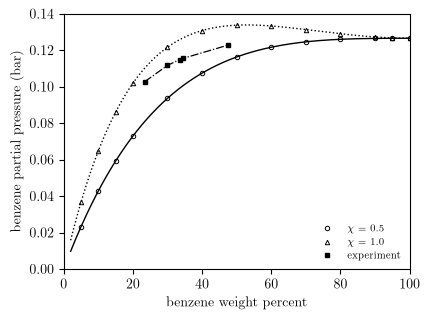

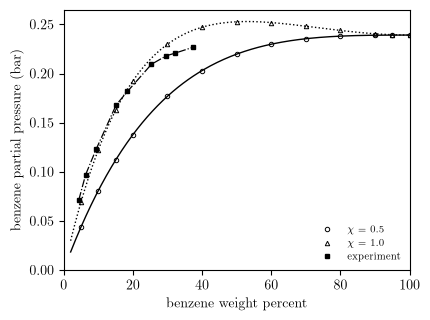

In [5]:
def figure(T):
    """Illustration 10.2-7's figure at one temperature."""
    fig, ax = plt.subplots(figsize=(4.4, 3.3))
    w = np.linspace(2.0, 100.0, 200)
    styles = {0.5: dict(ls="-", lw=1.0, marker="o"), 1.0: dict(ls=":", lw=1.0, marker="^")}
    for chi in CHIS:
        p = np.array([partial_pressure(a / 100.0, chi, T) for a in w])
        ax.plot(w, p, color="k", ls=styles[chi]["ls"], lw=styles[chi]["lw"])
        pm = np.array([partial_pressure(a / 100.0, chi, T) for a in WT_CALC])
        ax.plot(WT_CALC, pm, styles[chi]["marker"], mfc="none", mec="k", mew=0.7, ms=3.2,
                lw=0, label=f"$\\chi$ = {chi}")
    d = EXPT[T]
    ax.plot(d[:, 0], d[:, 1], "-.", color="k", lw=0.9)
    ax.plot(d[:, 0], d[:, 1], "s", color="k", ms=3.0, lw=0, label="experiment")
    ax.set_xlabel("benzene weight percent")
    ax.set_ylabel("benzene partial pressure (bar)")
    ax.set_xlim(0, 100); ax.set_ylim(0, None)
    ax.legend(loc="lower right", frameon=False, fontsize=7, handlelength=2.6)
    fig.tight_layout()
    return fig

fig1 = figure(298.15)
fig2 = figure(312.75)

**Read the left-hand edge.** Both curves rise almost vertically out of the origin and then
flatten: by 40 weight percent benzene the partial pressure is already within about 15 % of the
pure-benzene vapor pressure, and from there to 100 % it barely moves. Turned around, that is
the devolatilization problem — the *last* few percent of solvent exerts almost no pressure, so
there is almost no driving force to remove it. Vacuum, heat, and time are what remain.

**The two $\chi$ values bracket the data rather than fit it.** At 298.15 K the measurements sit
between the $\chi = 0.5$ and $\chi = 1.0$ curves and closer to $\chi = 1.0$; at 312.75 K they
sit close to $\chi = 1.0$ over the range measured. Neither value is right everywhere, which is
the honest lesson about a one-parameter model: $\chi$ is not a constant of the pair, and
fitting it at one composition does not make it correct at another.

**The measurements are Eichinger and Flory's**, *Trans. Faraday Soc.* **64**, 2053–2060 (1968)
— named by the illustration itself, in the paragraph that follows its results table.

**Two independent confirmations that this is the right member of the series**, since the
1968 volume carries several papers with almost the same title. **Problem 10.2-23** cites the
*same page range* for benzene + polyisobutylene activity data at 10 °C — the same pair, the
same polymer molecular weight, a third temperature. And the two problems after it cite the
adjacent papers for the *other* solvents: 2061–2065 for cyclohexane (Problem 10.2-24) and
2066–2072 for *n*-pentane (Problem 10.2-25). The benzene member is 2053–2060.

**An earlier version of this notebook said these points had no source. That was
wrong** — the citation is one paragraph below the table, and the note is kept here rather than
deleted because the mistake was not a missing citation but a failure to read the surrounding
prose before asserting one was absent.

## Print art

In [6]:
# --- Print art: Illustration 10.2-7, Figures 1 and 2 ------------------------
#   pdf/Illustration_10.2-7_fig1.pdf -> print-bw/ch10/c10uf008.pdf   298.15 K
#   pdf/Illustration_10.2-7_fig2.pdf -> print-bw/ch10/c10uf009.pdf   312.75 K
# These were the last two pieces of illustration art still inherited as
# .eps; recomputing them flips both slugs to .pdf in c10.docx and ch10.yaml.
# Open markers on the computed curves, filled on the measurements, all pure black.
import os
os.makedirs("pdf", exist_ok=True)
for tag, f in (("fig1", fig1), ("fig2", fig2)):
    path = f"pdf/Illustration_10.2-7_{tag}.pdf"
    f.savefig(path, dpi=300, bbox_inches="tight")
    print("wrote", path)

wrote pdf/Illustration_10.2-7_fig1.pdf
wrote pdf/Illustration_10.2-7_fig2.pdf


## Your turn

1. Fit $\chi$ to the measurements at each temperature instead of bracketing it. How far apart
   are the two values, and does a single $\chi$ describe both isotherms?
2. $\chi$ is often written as $\chi = a + b/T$. Use your two fitted values to get $a$ and $b$,
   then predict the partial pressures at 60 $^\circ$C. What would you need to measure to check
   that prediction?
3. Set $m = 1$ in the Flory-Huggins expression, which turns it back into a regular-solution-like
   model on mole fractions, and redraw Figure 1. How badly does it fail, and where?
4. The illustration assumes the polymer is monodisperse, with every chain 40 000 g/mol. Real
   PIB is not. Repeat the calculation for a 50/50 mixture of 20 000 and 60 000 chains and
   decide whether polydispersity matters here at the precision of the table.
5. At what weight percent does the benzene partial pressure fall to 1 % of its pure vapor
   pressure? That composition, not zero, is what a devolatilizer has to reach.